In [13]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_lattice(ax):
    elements = [
        ("drift", 0.260),
        ("coll", 0.0025),
        ("drift", 0.3375),
        ("dipole", 0.628318),
        ("drift", 0.208),
        ("chopper", 0.150),
        ("drift", 0.140),
        ("drift", 0.722),
        ("collx", 0.002),
        ("drift", 0.002),
        ("colly", 0.002),
        ("drift", 0.194),
        ("quad", 0.140),
        ("drift", 0.092),
        ("quad", 0.140),
        ("drift", 0.092),
        ("quad", 0.140),
        ("drift", 0.9101),
        ("solenoid", 0.2574),
        ("drift", 0.1393),
    ]

    y_min, y_max = ax.get_ylim()

    height = 0.15 * (y_max - y_min)
    y0 = -height / 2  

    s_pos = 0

    for name, length in elements:
        s0 = s_pos
        s1 = s_pos + length

        if name == "dipole":
            color = "black"
            alpha = 0.25

        elif name == "quad":
            color = "black"
            alpha = 0.9

        elif name == "solenoid":
            color = "black"
            alpha = 0.5

        elif name.startswith("coll"):
            color = "gray"
            alpha = 0.6

        elif name == "chopper":
            color = "purple"
            alpha = 0.5

        else:
            s_pos = s1
            continue

        rect = plt.Rectangle(
            (s0, y0),
            s1 - s0,
            height,
            color=color,
            alpha=alpha
        )

        ax.add_patch(rect)

        s_pos = s1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parser

In [ ]:
datos = np.loadtxt("lebt.stat", skiprows=303)

s = datos[:, 1]
num_particles = datos[:, 2]
rms_x = datos[:, 5]      # m
rms_y = datos[:, 6]      # m
rms_px = datos[:, 8]     # normalized momentum in x
rms_py = datos[:, 9]     # normalized momentum in y
emit_x = datos[:, 11]    # normalized emittance
emit_y = datos[:, 12]    # normalized emittance
ref_px = datos[:, 20]    # reference normalized momentum in x
ref_py = datos[:, 21]    # reference normalized momentum in y
ref_pz = datos[:, 22]    # reference normalized momentum in z

# Input Point
s_input = s[0]

sigma_x_opal_input = rms_x[0] * 1e3   # m -> mm
sigma_y_opal_input = rms_y[0] * 1e3   # m -> mm

p_ref_input = np.sqrt(ref_px[0]**2 + ref_py[0]**2 + ref_pz[0]**2)

# x' ≈ px / |p|, y' ≈ py / |p|
sigma_xp_opal_input = (rms_px[0] / p_ref_input) * 1e3   # rad -> mrad
sigma_yp_opal_input = (rms_py[0] / p_ref_input) * 1e3   # rad -> mrad

emit_x_opal_input = emit_x[0] * 1e6   # m rad -> mm mrad
emit_y_opal_input = emit_y[0] * 1e6   # m rad -> mm mrad

print("OPAL input values")
print("-----------------")
print(f"Beam horizontal rms-size        sigma_x  = {sigma_x_opal_input:.6f} mm")
print(f"Beam vertical rms-size          sigma_y  = {sigma_y_opal_input:.6f} mm")
print(f"Beam horizontal rms-divergence  sigma_x' = {sigma_xp_opal_input:.6f} mrad")
print(f"Beam vertical rms-divergence    sigma_y' = {sigma_yp_opal_input:.6f} mrad")
print(f"Beam horizontal normalized emittance: emit_x = {emit_x_opal_input:.6f} mm mrad")
print(f"Beam vertical normalized emittance:   emit_y = {emit_y_opal_input:.6f} mm mrad")

print()

# ------------------------------------------------------------
# Final point
# ------------------------------------------------------------
s_final = s[-1]

sigma_x_opal = rms_x[-1] * 1e3   # m -> mm
sigma_y_opal = rms_y[-1] * 1e3   # m -> mm

p_ref = np.sqrt(ref_px[-1]**2 + ref_py[-1]**2 + ref_pz[-1]**2)

# x' ≈ px / |p|, y' ≈ py / |p|
sigma_xp_opal = (rms_px[-1] / p_ref) * 1e3   # rad -> mrad
sigma_yp_opal = (rms_py[-1] / p_ref) * 1e3   # rad -> mrad

emit_x_opal = emit_x[-1] * 1e6   # m rad -> mm mrad
emit_y_opal = emit_y[-1] * 1e6   # m rad -> mm mrad

print("OPAL final values")
print("-----------------")
print(f"Beam horizontal rms-size        sigma_x  = {sigma_x_opal:.6f} mm")
print(f"Beam vertical rms-size          sigma_y  = {sigma_y_opal:.6f} mm")
print(f"Beam horizontal rms-divergence  sigma_x' = {sigma_xp_opal:.6f} mrad")
print(f"Beam vertical rms-divergence    sigma_y' = {sigma_yp_opal:.6f} mrad")
print(f"Beam horizontal normalized emittance: emit_x = {emit_x_opal:.6f} mm mrad")
print(f"Beam vertical normalized emittance:   emit_y = {emit_y_opal:.6f} mm mrad")

OPAL final values
-----------------
Beam horizontal rms-size        sigma_x  = 1.181582 mm
Beam vertical rms-size          sigma_y  = 0.617943 mm
Beam horizontal rms-divergence  sigma_x' = 60.904299 mrad
Beam vertical rms-divergence    sigma_y' = 45.250309 mrad
Beam horizontal normalized emittance: emit_x = 0.369690 mm mrad
Beam vertical normalized emittance:   emit_y = 0.158982 mm mrad


## Plots

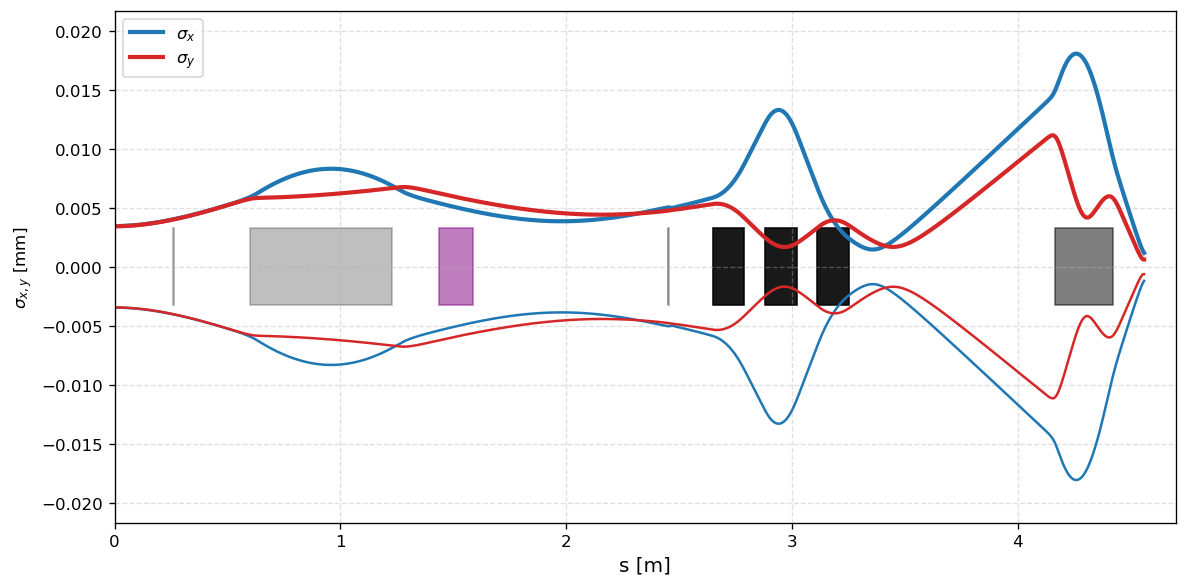

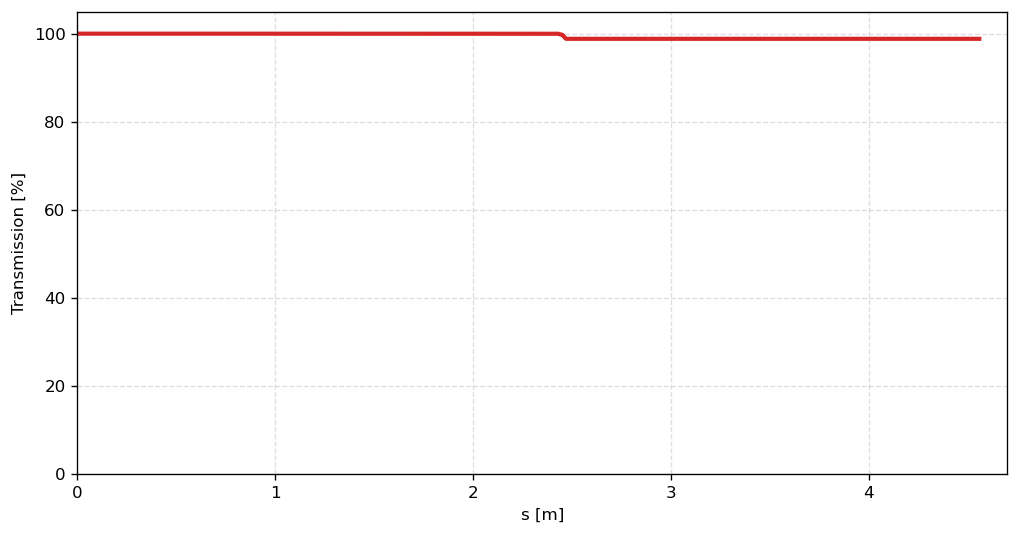

In [15]:
results_dir = Path.cwd().resolve().parent / "beam_plots"
results_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
color_x = 'tab:blue'
color_y = 'tab:red'
ax.plot(s,  rms_x, color=color_x,linewidth=2.5, label=r'$\sigma_x$')
ax.plot(s, -rms_x, color=color_x,linewidth=1.5)
ax.plot(s,  rms_y, color=color_y, linewidth=2.5, label=r'$\sigma_y$')
ax.plot(s, -rms_y, color=color_y, linewidth=1.5)
ax.set_xlabel('s [m]',fontsize=12)
ax.set_ylabel(r'$\sigma_{x,y}$ [mm]')
ax.set_xlim(0, 4.7)
ax.set_ylim(-max(rms_x)*1.2, max(rms_x)*1.2)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plot_lattice(ax)
fig.savefig(results_dir / "opal_lebt_lattice.png", bbox_inches="tight")
plt.show()

# transmission plot
plt.figure(figsize=(10, 5), dpi=120)
plt.plot(s, N/N[0]*100, color="tab:red",linewidth=2.5)
plt.xlabel('s [m]')
plt.ylabel('Transmission [%]')
plt.xlim(0, 4.7) 
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig(results_dir / "opal_lebt_transmission.png", bbox_inches="tight")
plt.show()